In [3]:
import sys
!{sys.executable} -m pip install PyPDF2

In [4]:
import PyPDF2

# Define the path to the PDF file
pdf_file_path = '/content/main.pdf'

# Initialize a variable to store the extracted text
extracted_text = ""

try:
    # Open the PDF file in read-binary mode
    with open(pdf_file_path, 'rb') as file:
        # Create a PDF reader object
        reader = PyPDF2.PdfReader(file)

        # Get the number of pages in the PDF
        num_pages = len(reader.pages)
        print(f"Number of pages in the PDF: {num_pages}")

        # Extract text from each page (e.g., first 5 pages to preview)
        for i in range(min(num_pages, 5)): # Extract up to 5 pages
            page = reader.pages[i]
            extracted_text += page.extract_text() + "\n---\n"

    # Display the extracted text
    print("\n--- Extracted Text Preview (First 5 pages or less) ---\n")
    print(extracted_text[:1000]) # Display first 1000 characters
    if len(extracted_text) > 1000:
        print("... [Text truncated] ...")

except FileNotFoundError:
    print(f"Error: The file '{pdf_file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Number of pages in the PDF: 12

--- Extracted Text Preview (First 5 pages or less) ---

T ugas Individu
Eksperimen Operasi Dasar pada Sinyal dan Citra
Mata Kuliah: Pengolahan Sinyal Digital
T opik
Operasi dasar pada sinyal dan citra, meliputi:
1. Operasi penjumlahan
2. Operasi penggeseran
3. Operasi amplifikasi
4. Superposisi
5. Sistem linier
6. Aplikasi nyata pada sinyal dan citra
Deskripsi T ugas
Setiap mahasiswa diminta membuat eksperimen berbasis Python untuk menerapkan
operasi dasar pada sinyal 1D dan citra 2D.
T ugas ini tidak hanya menilai kemampuan mahasiswa dalam menulis kode, tetapi
juga kemampuan mahasiswa dalam menganalisis efek setiap operasi terhadap sinyal
dan citra.
Mahasiswa wajib membuat visualisasi, membandingkan hasil, dan menjelaskan
makna dari setiap operasi secara teknis dan konseptual.
F okus utama tugas ini adalah agar mahasiswa mampu memahami bahwa operasi
sederhana seperti penjumlahan, penggeseran, dan amplifikasi merupakan dasar dari
konsep yang lebih besar 

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

1. PENGATURAN DEVICE & HYPERPARAMETER

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 15
batch_size = 64
learning_rate = 1e-3

2. LOAD DATASET FASHION-MNIST

In [7]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 274kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.03MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 2.70MB/s]


3. ARSITEKTUR AUTOENCODER (FLEKSIBEL UNTUK BERBAGAI LATENT DIM)

In [8]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
    def forward(self, x):
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = self.fc(x)
        return x.view(-1, 1, 28, 28)

class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

4. PROSES TRAINING UNTUK DIMENSI LATEN: 2, 8, dan 32

In [9]:
latent_dims = [2, 8, 32]
history = {}
tabel_hasil = []

for latent_dim in latent_dims:
    print(f"\n=== Melatih Model dengan Latent Dimension: {latent_dim} ===")
    model = Autoencoder(latent_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    loss_epochs = []
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for data, _ in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, data)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * data.size(0)

        train_loss /= len(train_loader.dataset)
        loss_epochs.append(train_loss)
        if (epoch+1) % 5 == 0 or epoch == 1:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss:.4f}")

    history[latent_dim] = loss_epochs
    final_loss = loss_epochs[-1]
    tabel_hasil.append((latent_dim, final_loss))

    # Menentukan catatan kualitas visual secara terprogram untuk tabel laporan
    kualitas = "Buram/Siluet keras" if latent_dim == 2 else "Cukup Jelas" if latent_dim == 8 else "Sangat Detail & Bersih"
    print(f"Loss Akhir Dim {latent_dim}: {final_loss:.4f} -> Kualitas: {kualitas}")

    # Simpan bobot terpisah sesuai instruksi tugas
    torch.save(model.state_dict(), f"autoencoder_fashion_mnist_{latent_dim}.pth")
    torch.save(model.encoder.state_dict(), f"encoder_fashion_mnist_{latent_dim}.pth")
    torch.save(model.decoder.state_dict(), f"decoder_fashion_mnist_{latent_dim}.pth")


=== Melatih Model dengan Latent Dimension: 2 ===
Epoch [2/15], Loss: 0.0291
Epoch [5/15], Loss: 0.0270
Epoch [10/15], Loss: 0.0255
Epoch [15/15], Loss: 0.0247
Loss Akhir Dim 2: 0.0247 -> Kualitas: Buram/Siluet keras

=== Melatih Model dengan Latent Dimension: 8 ===
Epoch [2/15], Loss: 0.0170
Epoch [5/15], Loss: 0.0140
Epoch [10/15], Loss: 0.0129
Epoch [15/15], Loss: 0.0124
Loss Akhir Dim 8: 0.0124 -> Kualitas: Cukup Jelas

=== Melatih Model dengan Latent Dimension: 32 ===
Epoch [2/15], Loss: 0.0160
Epoch [5/15], Loss: 0.0116
Epoch [10/15], Loss: 0.0094
Epoch [15/15], Loss: 0.0085
Loss Akhir Dim 32: 0.0085 -> Kualitas: Sangat Detail & Bersih


5. GRAFIK TRAINING LOSS & VISUALISASI REKONSTRUKSI

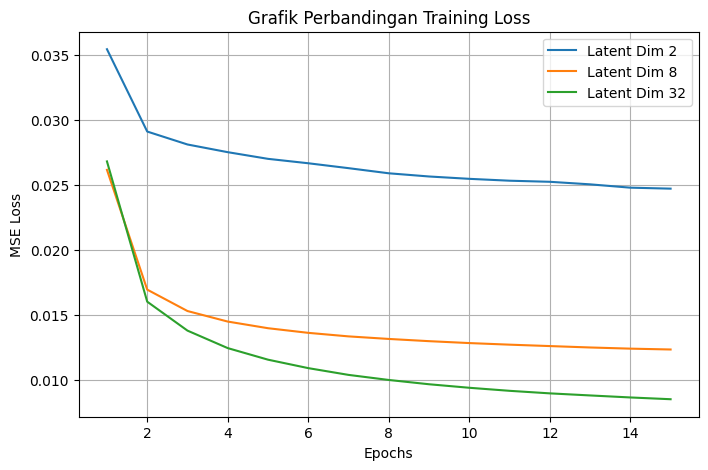

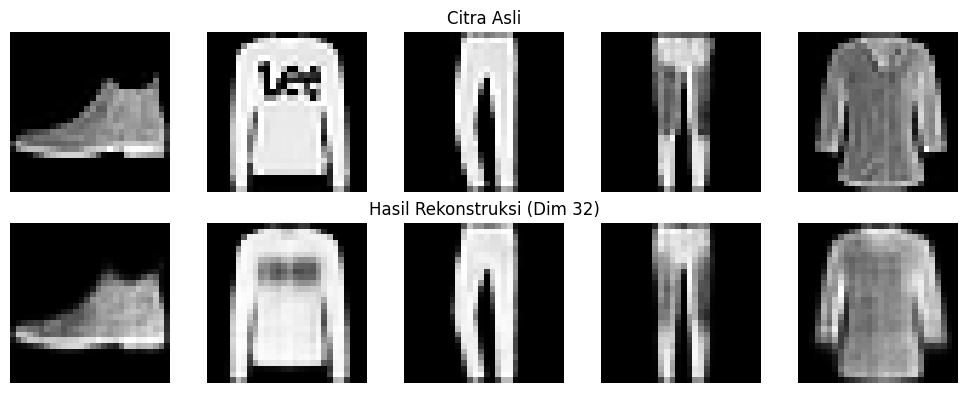


=== Selesai! Cetak data di bawah ini untuk Tabel Laporan Anda ===
Latent Dim | Loss Akhir
        2 | 0.0247
        8 | 0.0124
       32 | 0.0085


In [10]:
plt.figure(figsize=(8, 5))
for latent_dim in latent_dims:
    plt.plot(range(1, epochs+1), history[latent_dim], label=f'Latent Dim {latent_dim}')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Grafik Perbandingan Training Loss')
plt.legend()
plt.grid(True)
plt.savefig('training_loss_comparison.png')
plt.show()

# Tampilkan contoh hasil rekonstruksi model terbaik (dimensi 32)
model.eval()
with torch.no_grad():
    data, _ = next(iter(test_loader))
    data = data.to(device)
    recon = model(data)

    fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 4))
    for i in range(5):
        axes[0, i].imshow(data[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off')
        if i == 2: axes[0, i].set_title("Citra Asli")

        axes[1, i].imshow(recon[i].cpu().squeeze(), cmap='gray')
        axes[1, i].axis('off')
        if i == 2: axes[1, i].set_title("Hasil Rekonstruksi (Dim 32)")
    plt.tight_layout()
    plt.savefig('reconstruction_sample.png')
    plt.show()

print("\n=== Selesai! Cetak data di bawah ini untuk Tabel Laporan Anda ===")
print("Latent Dim | Loss Akhir")
for row in tabel_hasil:
    print(f"{row[0]:9} | {row[1]:.4f}")